# 实验19: 基于ResNet-18微调的脑部肿瘤 MRI 影像分类

**实验性质**: 设计性实验 (Design Experiment)  
**核心模型**: ResNet-18 (Residual Network)  
**技术点**: 迁移学习 (Transfer Learning) + 微调 (Fine-tuning)  
**任务**: 对高分辨率的内部结构扫描图进行 4 分类

## 1. 实验背景与意义

###  知识点：ResNet 与残差连接
随着神经网络层数变深，会出现“梯度消失”和“网络退化”问题（即层数越深，效果反而越差）。**ResNet (残差网络)** 通过引入 **Skip Connection (跳跃连接)**，让数据可以跨层直接传递（$y = F(x) + x$），成功训练了上百层的网络。

###  为什么需要迁移学习？
在工业检测或特殊成像领域，我们往往没有百万级的标注数据（像 ImageNet 那样）。
**迁移学习**的核心思想是：站在巨人的肩膀上。我们利用在通用大数据上训练好的 ResNet-18 提取“通用特征”（如边缘、纹理），然后冻结大部分参数，只针对我们特定的**“结构扫描图像”**进行**微调 (Fine-tuning)**。这能极大减少训练时间，并提高小样本下的准确率。

###  为什么要进行微调（Fine-tuning）？
医疗影像数据通常较少（几千张），直接从头训练深层网络容易导致过拟合（Overfitting）。
ImageNet: 拥有1000类、120万张自然图像，模型从中学会了边缘、纹理、形状等通用特征。
迁移策略: 我们保留 ResNet-18 的卷积基（Backbone）用于提取特征，仅重新训练最后的全连接分类层（Head），使其适应 MRI 的 4 分类任务。

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import os
from tqdm import tqdm  # 用于显示进度条

# 1. 设置设备：优先使用 GPU (CUDA/MPS)，否则使用 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"当前使用的计算设备: {device}")

# 2. 设置随机种子，保证实验可复现
torch.manual_seed(42)
np.random.seed(42)

当前使用的计算设备: cuda


## 2. 数据加载与预处理

**注意**：我们使用的数通常是单通道（灰度）的。但 ResNet-50 在 ImageNet 上训练时是 3 通道（RGB）输入。
因此，在 `transforms` 中，我们需要确保图像被转换为 3 通道格式（通常 PyTorch 的 `ImageFolder` 加载时会自动把灰度图转为 3 通道 RGB 格式，数值 R=G=B）。

**目录结构假设**：
请确保你的数据集解压在 `../data` 下，且包含 `Training` 和 `Testing` 两个子文件夹。

In [11]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. 定义具体的路径（指向包含具体类别文件夹的父目录）
# 注意：路径中不要包含中文，如果是在 Windows 上运行，建议使用绝对路径或确保相对路径正确
TRAIN_PATH = '../data/Training' 
TEST_PATH = '../data/Testing'

# 2. 定义图像预处理流程
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),       
        transforms.RandomHorizontalFlip(),   
        transforms.RandomRotation(10),       
        transforms.ToTensor(),               
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 3. 分别加载训练集和验证集（不再使用 random_split）
try:
    # 直接读取 Training 文件夹，它下面有 4 个分类文件夹，所以会自动识别为 4 类
    train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=data_transforms['train'])
    
    # 直接读取 Testing 文件夹
    val_dataset = datasets.ImageFolder(TEST_PATH, transform=data_transforms['val'])

    # 创建 DataLoader
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    # 验证集通常不需要 shuffle=True
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

    class_names = train_dataset.classes
    print(f" 成功加载数据！")
    print(f"类别名称: {class_names}")  # 这里应该显示 4 个肿瘤类别了
    print(f"训练集数量: {len(train_dataset)}")
    print(f"验证集数量: {len(val_dataset)}")
    
except Exception as e:
    print(f" 错误: 无法加载数据。")
    print(f"请检查路径是否存在:\n {os.path.abspath(TRAIN_PATH)}\n {os.path.abspath(TEST_PATH)}")
    print(f"详细错误: {e}")

 成功加载数据！
类别名称: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
训练集数量: 2870
验证集数量: 394


## 3. 数据可视化 (EDA)

在训练前，我们必须检查一下输入图像。因为做了 Normalization，图片颜色看起来会有点“怪”（这是正常的数学变换结果）。

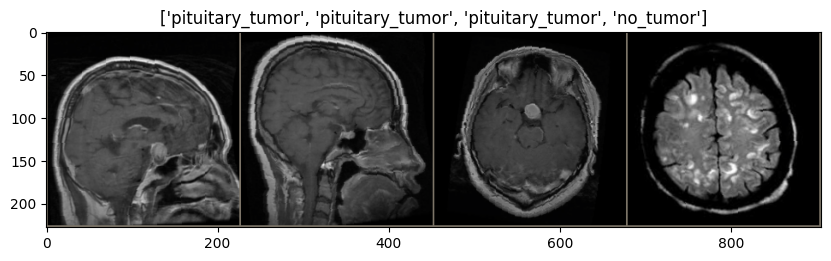

In [12]:
# --- 添加这几行导入代码 ---
import torchvision
import matplotlib.pyplot as plt
import numpy as np
# ------------------------

def imshow(inp, title=None):
    """用于显示 Tensor 图像的辅助函数"""
    inp = inp.numpy().transpose((1, 2, 0)) # 转换维度: (C, H, W) -> (H, W, C)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean  # 反归一化，为了正常显示颜色
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.pause(0.001)

# 获取一个 Batch 的数据
# 注意：确保 train_loader 和 class_names 已经在之前的单元格中定义并运行过
if 'train_loader' in locals():
    inputs, classes = next(iter(train_loader))

    # 制作网格图
    out = torchvision.utils.make_grid(inputs[:4]) # 只显示前4张
    plt.figure(figsize=(10, 5))
    
    # 这里的 title 生成逻辑需要确保 class_names 存在
    if 'class_names' in locals():
        imshow(out, title=[class_names[x] for x in classes[:4]])
    else:
        imshow(out, title="Class names not found")
else:
    print("错误: train_loader 未定义，请先运行数据加载部分的单元格。")

## 4. 构建模型：ResNet-18 微调

这是本实验的核心步骤。
1.  **下载预训练模型**: 加载在 ImageNet 上训练好的 ResNet-18 参数。
2.  **冻结参数 (Freeze)**: 锁住前面的卷积层，不让它们更新（因为它们已经学会了如何看线条和形状）。
3.  **替换全连接层 (FC Head)**: 将最后输出 1000 类（ImageNet）的一层，换成输出 **4 类**（我们的任务）。

In [13]:
from torchvision.models import resnet50, ResNet50_Weights

# 1. 加载预训练模型
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# 2. 冻结所有模型参数 (Feature Extractor)
for param in model.parameters():
    param.requires_grad = False

# 3. 修改最后的全连接层 (Classifier)
# ResNet50 的 fc 输入特征数是 2048
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names)) # 新的层默认 requires_grad=True

model = model.to(device)

# 4. 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
# 注意：优化器只更新 model.fc 的参数，因为其他层被冻结了
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("模型构建完成。仅最后一层全连接层参数参与训练。")

模型构建完成。仅最后一层全连接层参数参与训练。


## 5. 模型训练

由于我们只训练最后一层，计算量很小，收敛会非常快。
如果你有 GPU，几分钟就能跑完 15 个 Epoch。
重点：观察 Train Loss 和 Val Loss 的变化。如果 Train Loss 持续下降但 Val Loss 上升，说明发生了过拟合。

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os
from tqdm import tqdm
import copy

# =================配置区域=================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 15           # ResNet-18 收敛快，15轮足够
BATCH_SIZE = 32
LEARNING_RATE = 0.001
# =========================================

# 1. 定义数据预处理 (关键：增加了训练集的数据增强)
# 注意：这里假设你之前的 dataset/loader 已经在上面的单元格定义好了
# 但为了确保效果，建议重新定义 transforms 并重新生成 loader
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),      # 随机水平翻转
        transforms.RandomRotation(15),          # 随机旋转
        transforms.ColorJitter(brightness=0.1), # 亮度微调
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 重新加载数据 (确保路径正确)
# 假设你的目录结构是 ./data/Training 和 ./data/Testing
image_datasets = {
    'train': datasets.ImageFolder(os.path.join('../data', 'Training'), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join('../data', 'Testing'), data_transforms['val'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
num_classes = len(class_names)

print(f"检测到类别数: {num_classes} {class_names}")

# 2. 初始化 ResNet-18 模型 (替换掉原来的 ResNet-50)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes) # 替换最后一层
model = model.to(DEVICE)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 3. 改进后的训练函数
def train_model(model, criterion, optimizer, num_epochs=10):
    # 记录历史数据
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # 每个 epoch 分为训练和验证两个阶段
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # 训练模式
            else:
                model.eval()   # 验证模式

            running_loss = 0.0
            running_corrects = 0

            # 迭代数据
            # 如果是 train 阶段显示进度条，val 阶段通常不需要
            data_iter = tqdm(dataloaders[phase], desc=f"{phase.capitalize()}") if phase == 'train' else dataloaders[phase]

            for inputs, labels in data_iter:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                # 梯度清零
                optimizer.zero_grad()

                # 前向传播
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # 只在训练阶段反向传播和优化
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # 统计损失和准确率
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            # 存入历史记录
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                print(f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                print(f"Val   Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

                # 深度拷贝模型（只保存验证集表现最好的那一次）
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(model.state_dict(), 'best_model.pth')
                    print(f"--> 新的最佳模型已保存 (Acc: {best_acc:.4f})")
        
        print() # 空行分隔

    print(f'训练结束。最佳验证集准确率: {best_acc:.4f}')
    
    # 加载最佳模型权重返回
    model.load_state_dict(best_model_wts)
    return model, history

# 4. 开始训练
trained_model, history = train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS)

检测到类别数: 4 ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\86177/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:10<00:00, 4.57MB/s]


Epoch 1/15
----------


Train: 100%|██████████| 90/90 [01:17<00:00,  1.16it/s]


Train Loss: 0.4871 Acc: 0.8185
Val   Loss: 1.5205 Acc: 0.5228
--> 新的最佳模型已保存 (Acc: 0.5228)

Epoch 2/15
----------


...

Train Loss: 0.0859 Acc: 0.9728
Val   Loss: 1.8817 Acc: 0.7005

Epoch 14/15
----------


Train: 100%|██████████| 90/90 [01:02<00:00,  1.45it/s]


Train Loss: 0.0568 Acc: 0.9787
Val   Loss: 1.2785 Acc: 0.7792

Epoch 15/15
----------


Train: 100%|██████████| 90/90 [01:04<00:00,  1.40it/s]


Train Loss: 0.0771 Acc: 0.9763
Val   Loss: 1.8147 Acc: 0.7462

训练结束。最佳验证集准确率: 0.7843


可用数据键值: dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc'])


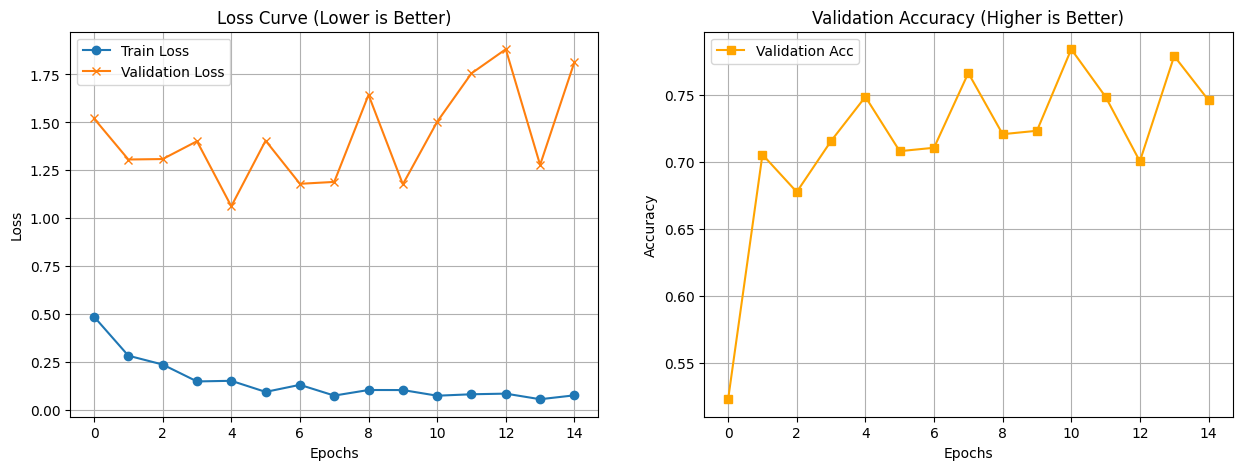

In [31]:
# 检查 history 中实际包含了哪些 key
print(f"可用数据键值: {history.keys()}")

plt.figure(figsize=(15, 5))

# --- 子图 1: 损失 Loss (训练 vs 验证) ---
plt.subplot(1, 2, 1)
if 'train_loss' in history and 'val_loss' in history:
    plt.plot(history['train_loss'], label='Train Loss', marker='o')
    plt.plot(history['val_loss'], label='Validation Loss', marker='x')
    plt.title("Loss Curve (Lower is Better)")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
else:
    print("无法绘制 Loss 曲线：缺少数据")

# --- 子图 2: 准确率 Accuracy (仅验证集) ---
plt.subplot(1, 2, 2)
if 'val_acc' in history:
    # 注意：之前的代码里没有计算 'train_acc'，所以这里只画验证集
    plt.plot(history['val_acc'], label='Validation Acc', color='orange', marker='s')
    plt.title("Validation Accuracy (Higher is Better)")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
else:
    print("无法绘制 Accuracy 曲线：缺少数据")

plt.show()

## 6. 模型评估与混淆矩阵
设计说明： 准确率（Accuracy）在医疗诊断中是不够的。我们需要看混淆矩阵（Confusion Matrix），了解模型是否容易将“肿瘤”误判为“无肿瘤”，或者混淆不同类型的肿瘤。

分类报告 (Classification Report):
                  precision    recall  f1-score   support

    glioma_tumor       0.91      0.29      0.44       100
meningioma_tumor       0.72      0.99      0.84       115
        no_tumor       0.74      1.00      0.85       105
 pituitary_tumor       0.98      0.82      0.90        74

        accuracy                           0.78       394
       macro avg       0.84      0.78      0.76       394
    weighted avg       0.82      0.78      0.75       394

混淆矩阵 (Confusion Matrix):
[[ 29  40  30   1]
 [  0 114   1   0]
 [  0   0 105   0]
 [  3   4   6  61]]


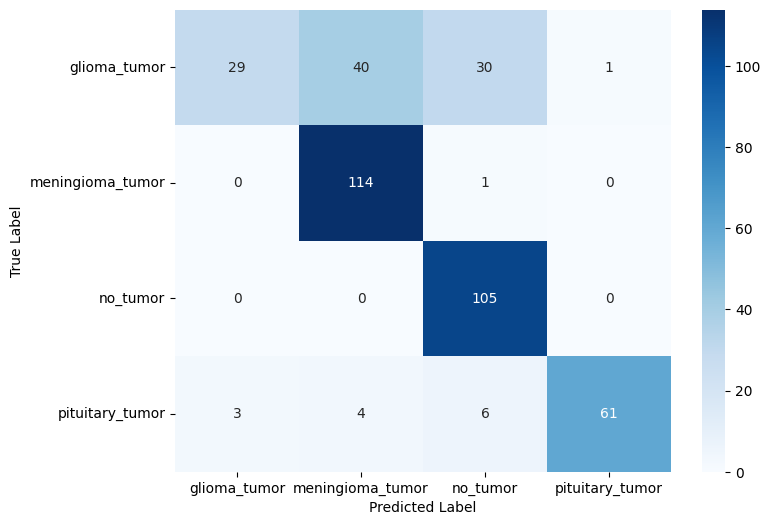

In [32]:
y_true = []
y_pred = []

trained_model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = trained_model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 生成分类报告
print("分类报告 (Classification Report):")
print(classification_report(y_true, y_pred, target_names=class_names))

# 生成混淆矩阵
print("混淆矩阵 (Confusion Matrix):")
cm = confusion_matrix(y_true, y_pred)
print(cm)

# 可视化混淆矩阵
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 7. 结果可视化与评估

我们从测试集中随机抽取几张图片，看看模型预测得对不对。

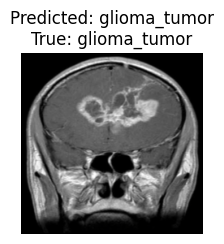

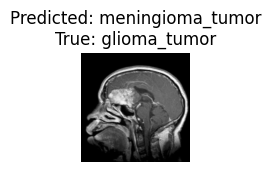

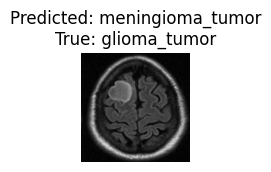

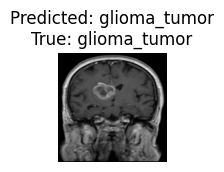

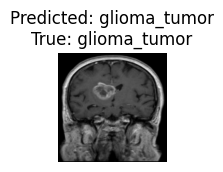

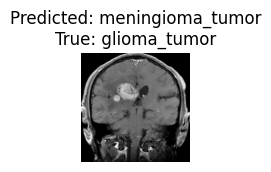

In [33]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(12, 8))

    with torch.no_grad():
        # 之前代码里没有 dataloaders 字典，只有独立的 val_loader
        for i, (inputs, labels) in enumerate(val_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size(0)):
                images_so_far += 1
                # 简单的子图逻辑
                ax = plt.subplot(num_images//3 + 1, 3, images_so_far)
                ax.axis('off')
                ax.set_title(f'Predicted: {class_names[preds[j]]}\nTrue: {class_names[labels[j]]}')
                # 调用之前的 imshow 函数
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)
# 如果你已经跑完了训练循环，建议用 trained_model
# 如果没跑训练，只是想测试代码，用 model
if 'trained_model' in locals():
    visualize_model(trained_model)
else:
    print("使用未训练的初始模型进行演示:")
    visualize_model(model)

## 8. 学生拓展与思考

### 🤔 思考题

1.  **关于输入通道**：
    我们的原始数据是**灰度图**（单通道），但 ResNet-50 要求的输入是 **3 通道**。代码中是如何解决这个问题的？如果强行把 ResNet 第一层改成接受单通道，需要怎么操作？

2.  **关于冻结权重 (Freezing)**：
    在代码中我们使用了 `param.requires_grad = False`。如果我们不冻结参数，直接训练整个网络，会发生什么后果？（提示：考虑数据集大小与过拟合）。

3.  **模型选择**：
    ResNet-50 层数很深。对于这种简单的 4 分类任务，如果换成 **ResNet-18** 甚至 **MobileNet**，效果会变差还是变好？

4.  **如果模型预测“无肿瘤”非常准，但预测“胶质瘤”很差，可能是什么原因？**


### 💡 解答思路

<details>
<summary><strong>点击查看参考答案</strong></summary>

#### 1. 输入通道问题
* **当前方案**: PyTorch 的 `ImageFolder` 使用 PIL 加载图片，默认会将灰度图转换为 RGB (3通道，数值相同)。
* **修改网络方案**: 可以修改 `model.conv1`。原版是 `nn.Conv2d(3, 64, ...)`，可以手动将其替换为 `nn.Conv2d(1, 64, ...)`，但这样会导致预训练的权重维度不匹配，第一层的参数必须重新从头训练。

#### 2. 冻结 vs 全量微调
* 如果不冻结，我们需要在仅有的几千张图片上更新 ResNet 所有的 2500万个参数。
* **后果**: 极易**过拟合 (Overfitting)**，模型会死记硬背训练集，导致测试集准确率下降。且训练速度会慢几十倍。

#### 3. 模型选择
* 对于这种纹理清晰、类别较少的任务，**ResNet-18 可能效果更好且更快**。ResNet-50 可能会有“杀鸡用牛刀”的感觉，参数冗余。

#### 4. 如果模型预测“无肿瘤”非常准，但预测“胶质瘤”很差
* 数据不平衡： 检查数据集，是否“无肿瘤”的图片远多于“胶质瘤”？如果是，模型会倾向于预测多数类。
* 特征相似性： 胶质瘤的形态可能与其他肿瘤或脑组织过于相似，模型难以区分。 解决方法： 可以尝试在 CrossEntropyLoss 中加入 weight 参数，给少样本类别更高的权重。

</details>